## 9. Interpolation

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=XstK9M4jzBY&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience09.png)](https://www.youtube.com/watch?v=XstK9M4jzBY&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

Interpolation erzeugt neue Vorhersagepunkte aus einer diskreten Menge bekannter Datenpunkte. Es gibt viele Arten der Interpolation, z. B. nächster Nachbar (Nearest Neighbor), linear, polynomiell, [kubischer Spline](https://apmonitor.com/wiki/index.php/Main/ObjectCspline) und [B-spline](https://apmonitor.com/wiki/index.php/Main/ObjectBspline). 
Bei der Interpolation liefern die Daten die Form der approximierenden Funktion; stückweise oder höhergradige Polynomgleichungen passen die Datenpunkte an den gegebenen diskreten Stellen exakt an.


![charge](https://apmonitor.com/che263/uploads/Begin_Python/charge.png)


### 1D-Interpolation

Das Paket ``scipy.interpolate`` enthält eine Funktion für eindimensionale Interpolation (``interp1d``), bei der ``kind`` ``nearest``, ``previous``, ``next``, ``zero``, ``linear``, ``quadratic``, ``cubic`` oder eine Zahl von ``0–3`` sein kann.

In [2]:
import numpy as np
x = np.array([0,1,2,3,4,5])
y = np.array([0.1,0.25,0.3,0.5,1.0,0.9])

# 1D-Interpolation
from scipy.interpolate import interp1d
f = interp1d(x,y,kind='cubic')
print(f(4.5)) # predict at 4.5

1.0983333333333334


![analyze](https://apmonitor.com/che263/uploads/Begin_Python/analyze.png)

### 1D-Interpolation plotten

Mehrere 1D-Interpolationen werden grafisch dargestellt. Vergiss nicht, beim Plotten zusätzliche Punkte hinzuzufügen, z. B. ``xp = np.linspace(0, 5, 100)``, sonst wirkt alles wie eine lineare Interpolation.

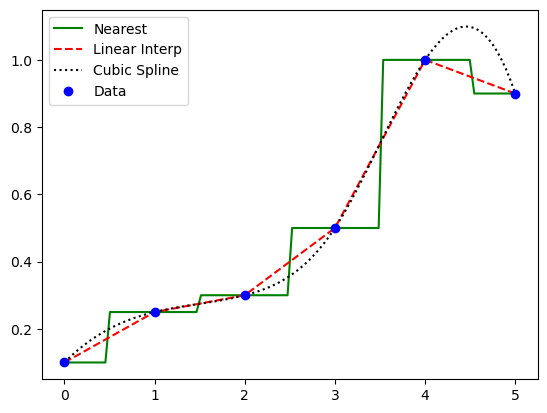

In [4]:
xp = np.linspace(0,5,100)
y1 = interp1d(x,y,kind='nearest')
y2 = interp1d(x,y,kind=1)
y3 = interp1d(x,y,kind=3)

import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(xp,y1(xp),'g-',label='Nearest')
plt.plot(xp,y2(xp),'r--',label='Linear Interp')
plt.plot(xp,y3(xp),'k:',label='Cubic Spline')
plt.plot(x,y,'bo',label='Data')
plt.legend()
plt.show()

Achtung: Beim Auslesen aus einer Interpolation kann ein Fehler auftreten – etwa
``ValueError: A value in x_new is above the interpolation range.`` – wenn du einen Wert außerhalb des Interpolationsbereichs anforderst (z. B. ``f(5.5)``).

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Interpolations-Übung

Erstelle eine lineare Interpolation mit den folgenden Daten.

```python
xr = [0.0,1.0,2.0,5.0]
yr = [0.2,0.4,1.05,1.7]
```

Verwende die Interpolation, um den Wert bei ``xr = 3.5`` vorherzusagen.

Interpolierter Wert bei x = 3.5: 1.4500


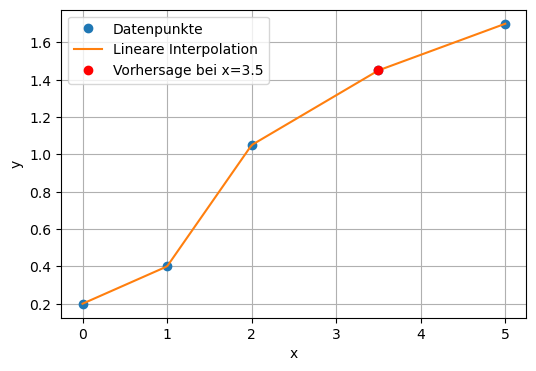

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Gegebene Daten
xr = np.array([0.0, 1.0, 2.0, 3.5, 5.0])
yr = np.array([0.2, 0.4, 1.05, 1.45, 1.7])

# Lineare Interpolation erstellen
f_linear = interp1d(xr, yr, kind='linear')

# Wert bei xr = 3.5 vorhersagen
x_pred = 3.5
y_pred = f_linear(x_pred)

print(f"Interpolierter Wert bei x = {x_pred}: {y_pred:.4f}")

# Plot zur Visualisierung
x_plot = np.linspace(min(xr), max(xr), 200)
y_plot = f_linear(x_plot)

plt.figure(figsize=(6,4))
plt.plot(xr, yr, 'o', label='Datenpunkte')
plt.plot(x_plot, y_plot, '-', label='Lineare Interpolation')
plt.plot(x_pred, y_pred, 'ro', label='Vorhersage bei x=3.5')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

![gekko](https://apmonitor.com/che263/uploads/Begin_Python/gekko.png)

Die Wahl des Splines ist für bestimmte Anwendungen wie Optimierung wichtig. Gradientenbasierte Solver arbeiten besser mit stetigen Funktionen mit stetigen Gradienten. Daher sind quadratische oder kubische Splines oft einer linearen Interpolation vorzuziehen.
Im Folgenden ein Beispiel für eine Optimierung mit einem kubischen Spline in Gekko. Die Originalfunktion ist 
 $\frac{1}{1+25 \, x^2}$ mit dem Ziel, das Maximum zu finden – unter Verwendung nur der Funktionswerte bei
`xr=[-1.0 -0.8 -0.5 -0.25 -0.1 0.1 0.2 0.5]`.

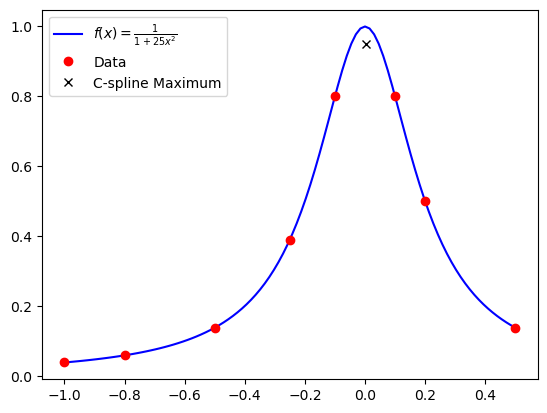

In [13]:
from gekko import GEKKO
import numpy as np
import matplotlib.pyplot as plt

# Daten erstellen
def f(x):
    return 1.0/(1.0+25.0*x**2)
xr = np.array([-1.0,-0.8,-0.5,-0.25,-0.1,0.1,0.2,0.5])
yr = f(xr)

# Erstelle einen kubischen Spline und maximiere die Funktion
c = GEKKO(remote=False)
xg = c.Var(); yg = c.Var()
c.cspline(xg,yg,xr,yr,True)
c.Maximize(yg)
c.solve(disp=False)

xp = np.linspace(-1,0.5,100)
plt.plot(xp,f(xp),'b-',label=r'$f(x) = \frac{1}{1+25x^2}$')
plt.plot(xr,yr,'ro',label='Data')
plt.plot(xg.value[0],yg.value[0],'kx',label='C-spline Maximum')
plt.legend(loc='best')
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Übung zum kubischen Spline

Erstelle einen kubischen Spline mit den folgenden Daten.

```python
xr = [0.0,1.0,2.0,3.0,4.0,5.0]
yr = [46.0,6.6,0.13,0.026,3.84,33.0]
```


Erstelle einen kubischen Spline und finde das Minimum der Funktion.

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### 2D-Interpolation

Es gibt auch eine Funktion zur zweidimensionalen Interpolation (``interp2d``), bei der ``kind`` entweder ``linear`` oder ``cubic`` ist.


In [18]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

x2 = np.arange(-1.5, 1.01, 0.5)
y2 = np.arange(-1.5, 1.01, 0.5)

xx, yy = np.meshgrid(x2, y2, indexing="ij")
zz = np.sin(xx**2 + yy**2)

f2 = RegularGridInterpolator((x2, y2), zz, method="linear")

point = np.array([[0.5, 1.0]])
z_pred = f2(point)

print(z_pred[0])

0.9489846193555862


![analyze](https://apmonitor.com/che263/uploads/Begin_Python/analyze.png)

### 2D-Interpolation plotten

Ein 3D-Diagramm zeigt die Datenpunkte in Rot (``red``) und die kubische Interpolation in Blau (``blue``). Der Plot enthält ein 3D-Streudiagramm für die Daten und ein Flächendiagramm für den kubischen Spline.

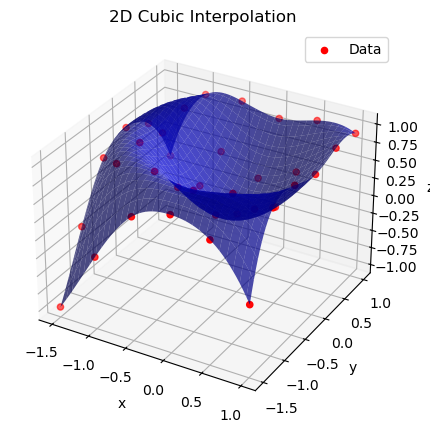

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# Alle alten Figures schließen (verhindert doppelte Ausgaben)
plt.close('all')

# Ursprüngliches grobes Gitter
x2 = np.arange(-1.5, 1.01, 0.5)
y2 = np.arange(-1.5, 1.01, 0.5)

xx, yy = np.meshgrid(x2, y2, indexing="ij")
zz = np.sin(xx**2 + yy**2)

# Kubischer Interpolator (robust gegen Rundungs-Out-of-bounds)
f2 = RegularGridInterpolator(
    (x2, y2),
    zz,
    method="cubic",
    bounds_error=False,
    fill_value=None
)

# Feinere Punkte für glatte Fläche (linspace statt arange)
xe = np.linspace(x2.min(), x2.max(), 60)
ye = np.linspace(y2.min(), y2.max(), 60)
xxe, yye = np.meshgrid(xe, ye, indexing="ij")

# Interpolierte Werte berechnen
pts = np.column_stack([xxe.ravel(), yye.ravel()])
fe = f2(pts).reshape(xxe.shape)

# Genau EIN Plot: Punkte + Fläche
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(xx, yy, zz, color="red", label="Data")
ax.plot_surface(xxe, yye, fe, color="blue", alpha=0.7)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("2D Cubic Interpolation")
ax.legend()

plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### TCLab-Übung

![temperature](https://apmonitor.com/che263/uploads/Begin_Python/temperature.png)

### Temperaturen aufzeichnen

Schalte Heizer 1 auf 100 % und zeichne $T_1$ und $T_2$ alle 10 Sekunden für 3 Minuten auf. Die Daten sollen insgesamt 19 Messpunkte pro Temperatursensor und die Messzeit enthalten, beginnend bei 0.

![connections](https://apmonitor.com/che263/uploads/Begin_Python/connections.png)

In [24]:
import time
import numpy as np

# Falls TCLab installiert ist:
from tclab import TCLab

# Messparameter
dt = 10.0          # Messintervall (Sekunden)
t_end = 180.0      # Gesamtdauer (3 Minuten)
n = int(t_end / dt) + 1  # inkl. Start bei t=0 -> 19 Messpunkte

# Arrays für Zeit und Temperaturen (19 Werte)
t = np.zeros(n)
T1 = np.zeros(n)
T2 = np.zeros(n)

with TCLab() as lab:
    # Heizer 1 auf 100%, Heizer 2 aus
    lab.Q1(100)
    lab.Q2(0)

    t0 = time.time()

    for k in range(n):
        # Zeit relativ zum Start (beginnt bei 0)
        t[k] = time.time() - t0

        # Temperaturen messen
        T1[k] = lab.T1
        T2[k] = lab.T2

        print(f"{k:2d}  t={t[k]:6.1f} s   T1={T1[k]:6.2f} °C   T2={T2[k]:6.2f} °C")

        # Warten bis zum nächsten Messpunkt (nicht nach dem letzten Punkt)
        if k < n - 1:
            next_time = t0 + (k + 1) * dt
            sleep_time = next_time - time.time()
            if sleep_time > 0:
                time.sleep(sleep_time)

    # Heizer ausschalten am Ende
    lab.Q1(0)
    lab.Q2(0)

print("Messung abgeschlossen.")

TCLab version 1.0.0
Arduino Leonardo connected on port COM5 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
 0  t=   0.0 s   T1= 46.03 °C   T2= 37.95 °C
 1  t=  10.0 s   T1= 45.13 °C   T2= 37.53 °C
 2  t=  20.0 s   T1= 45.07 °C   T2= 37.04 °C
 3  t=  30.0 s   T1= 45.71 °C   T2= 36.69 °C
 4  t=  40.0 s   T1= 46.97 °C   T2= 36.43 °C
 5  t=  50.0 s   T1= 48.52 °C   T2= 36.37 °C
 6  t=  60.0 s   T1= 50.23 °C   T2= 36.21 °C
 7  t=  70.0 s   T1= 51.90 °C   T2= 36.27 °C
 8  t=  80.0 s   T1= 53.77 °C   T2= 36.37 °C
 9  t=  90.0 s   T1= 55.64 °C   T2= 36.43 °C
10  t= 100.0 s   T1= 57.19 °C   T2= 36.66 °C
11  t= 110.0 s   T1= 58.83 °C   T2= 36.95 °C
12  t= 120.0 s   T1= 60.38 °C   T2= 37.33 °C
13  t= 130.0 s   T1= 61.83 °C   T2= 37.66 °C
14  t= 140.0 s   T1= 63.15 °C   T2= 37.95 °C
15  t= 150.0 s   T1= 64.44 °C   T2= 38.30 °C
16  t= 160.0 s   T1= 65.63 °C   T2= 38.62 °C
17  t= 170.0 s   T1= 66.66 °C   T2= 39.07 °C
18  t= 180.0 s   T1= 67.85 °C   T2= 39.56 °C
TCLab disconnected succe

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Interpolation

Erstelle eine Interpolationsfunktion zwischen den Messpunkten für $T_1$ mit linearer Interpolation. Zeige die aufgezeichneten $T_1$-Werte als rote Punkte und die lineare Interpolation als schwarze Linie. Füge x- und y-Beschriftungen sowie eine Legende hinzu.

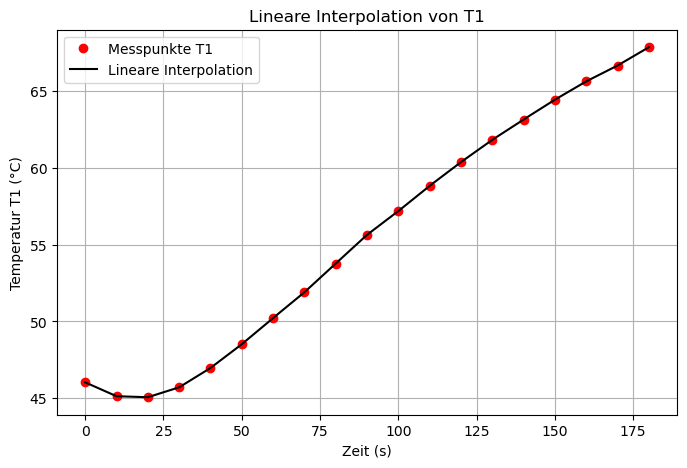

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Annahme: t und T1 stammen aus der vorherigen Messung
# (Arrays mit 19 Messpunkten)

# Lineare Interpolationsfunktion erstellen
f_lin = interp1d(t, T1, kind='linear')

# Feinere Zeitachse für glatte Linie
t_fine = np.linspace(t.min(), t.max(), 200)
T1_interp = f_lin(t_fine)

# Plot
plt.figure(figsize=(8,5))

# Original-Messpunkte (rot)
plt.plot(t, T1, 'ro', label='Messpunkte T1')

# Lineare Interpolation (schwarz)
plt.plot(t_fine, T1_interp, 'k-', label='Lineare Interpolation')

plt.xlabel('Zeit (s)')
plt.ylabel('Temperatur T1 (°C)')
plt.title('Lineare Interpolation von T1')
plt.legend()
plt.grid(True)

plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Interpolation vs. Regression

Erstelle eine Interpolationsfunktion zwischen den Messpunkten für $T_2$ mit einem kubischen Spline. Vergleiche den stückweisen kubischen Spline mit einer Polynom-Regression 3. Ordnung. Zeige die aufgezeichneten 
$T_2$-Werte als blaue Punkte, die kubische Spline-Interpolation als schwarze gestrichelte Linie und die Polynom-Regression als rote gepunktete Linie. Füge passende Achsenbeschriftungen und eine Legende hinzu.

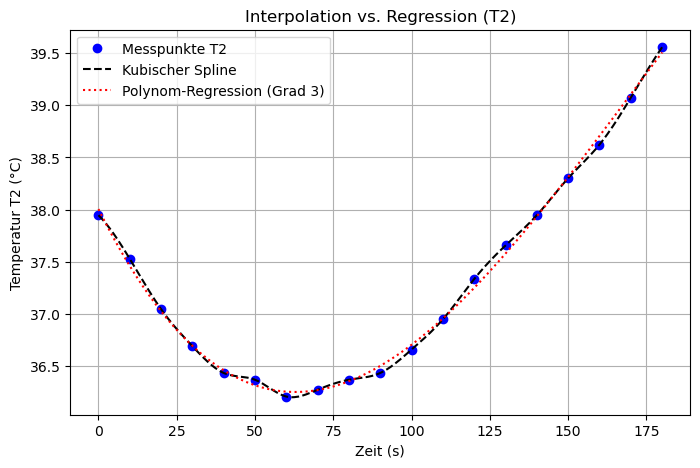

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Annahme: t und T2 stammen aus der vorherigen Messung
# (Arrays mit 19 Messpunkten)

# --- Kubischer Spline (stückweise kubisch) ---
cs = CubicSpline(t, T2)

t_fine = np.linspace(t.min(), t.max(), 300)
T2_spline = cs(t_fine)

# --- Polynom-Regression 3. Ordnung ---
coeffs = np.polyfit(t, T2, 3)
poly3 = np.poly1d(coeffs)
T2_poly = poly3(t_fine)

# --- Plot ---
plt.figure(figsize=(8,5))

# Messpunkte (blau)
plt.plot(t, T2, 'bo', label='Messpunkte T2')

# Kubischer Spline (schwarz gestrichelt)
plt.plot(t_fine, T2_spline, 'k--', label='Kubischer Spline')

# Polynom 3. Ordnung (rot gepunktet)
plt.plot(t_fine, T2_poly, 'r:', label='Polynom-Regression (Grad 3)')

plt.xlabel('Zeit (s)')
plt.ylabel('Temperatur T2 (°C)')
plt.title('Interpolation vs. Regression (T2)')
plt.legend()
plt.grid(True)

plt.show()